# 🎨 Color Detection Project
Upload any image and detect its dominant colors with percentages.

## Step 1: Install & Import Libraries

In [13]:
!pip install webcolors --quiet
import numpy as np
from PIL import Image   # Pillow (PIL) → opens image files (jpg, png, webp …) and converts them to numpy arrays
import io #lets us read the uploaded file bytes without saving to disk
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans # KMeans  → the ML algorithm that groups similar pixel colors together into K clusters (dominant colors)
import webcolors #webcolors → maps an RGB tuple like (255, 0, 0) → 'red' uses the full CSS3 color name database (~150 names)
from google.colab import files

print('All libraries loaded successfully!')

All libraries loaded successfully!


## Step 2: Upload Your Image

In [2]:
# Colab runs in the cloud, so we can't just give a file path. Fles.upload() pops up a browser dialog to pick a local file.

uploaded = files.upload()                          # shows upload button
filename  = list(uploaded.keys())[0]               # get the filename

# Open the raw bytes as a PIL Image and force it into RGB mode
# (some PNGs are RGBA — 4 channels; we only want 3)
img = Image.open(io.BytesIO(uploaded[filename])).convert('RGB')

print(f'📷 Loaded: {filename}')
print(f'   Size  : {img.width} × {img.height} px')
print(f'   Mode  : {img.mode}')

Saving Screenshot 2026-01-22 203730.png to Screenshot 2026-01-22 203730.png
📷 Loaded: Screenshot 2026-01-22 203730.png
   Size  : 1881 × 691 px
   Mode  : RGB


## Step 3: Resize & Flatten the Image into Pixels

In [3]:
# ── Why resize?
# 4K photo has ~8 million pixels. Running KMeans on all is slow and unnecessary 200×200 = 40 000 pixels → same colors, ~200× faster
# LANCZOS is the highest-quality downscale filter.

THUMB_SIZE = (200, 200)
img_small  = img.resize(THUMB_SIZE, Image.LANCZOS)

arr = np.array(img_small)

# Flatten to a list of pixels  →  shape: (40000, 3)
# Each row is one pixel: [R, G, B]
pixels = arr.reshape(-1, 3).astype(float)

print(f'Pixel matrix shape: {pixels.shape}')
print(f'Sample pixel (first): {pixels[0]}')

Pixel matrix shape: (40000, 3)
Sample pixel (first): [255.  83.  73.]


## Step 4: K-Means Clustering — Find Dominant Colors

In [4]:
# ── What is KMeans?
#    Think of it as sorting M&Ms by color without knowing how many
#    colors exist. You tell it K = 6 and it:
#      1. Randomly picks 6 'center' colors
#      2. Assigns every pixel to the nearest center
#      3. Moves each center to the average of its assigned pixels
#      4. Repeats until the centers stop moving
#    Result: K representative colors + which cluster each pixel belongs to.

K         = 6      # ← change this to detect more / fewer colors
N_INIT    = 10     # try 10 random starting points, pick the best run
MAX_ITER  = 300    # maximum iterations before stopping

kmeans = KMeans(n_clusters=K, n_init=N_INIT, max_iter=MAX_ITER, random_state=42)
kmeans.fit(pixels)

# cluster_centers_  → the K representative RGB colors  shape: (K, 3)
# labels_           → which cluster each pixel belongs to  shape: (40000,)

centers     = kmeans.cluster_centers_.astype(int)   # float → int (0-255)
labels      = kmeans.labels_

counts      = np.bincount(labels)                   # pixels per cluster
percentages = (counts / counts.sum() * 100)         # convert to %

print('KMeans done!')
print(f'Cluster sizes (pixels): {counts}')

KMeans done!
Cluster sizes (pixels): [15222  4191  6655  2133  8883  2916]


## Step 5: Map RGB → Human-Readable Color Name

In [8]:
# ── Why a custom function?
#    webcolors.rgb_to_name() only matches EXACT CSS colors (e.g. pure red 255,0,0). Real photos never have those. We need the CLOSEST name.
#    We compute Euclidean distance in 3D RGB space to every CSS3 color and return the nearest one.

def closest_color_name(rgb_tuple):
    r, g, b   = int(rgb_tuple[0]), int(rgb_tuple[1]), int(rgb_tuple[2])
    min_dist  = float('inf')
    best_name = 'unknown'

    for name in webcolors.names("css3"):
        cr, cg, cb = webcolors.name_to_hex(name), None, None
        cr, cg, cb = webcolors.hex_to_rgb(webcolors.name_to_hex(name))
        dist = ((cr - r)**2 + (cg - g)**2 + (cb - b)**2) ** 0.5
        if dist < min_dist:
            min_dist  = dist
            best_name = name

    return best_name

# Build results list, sorted by percentage descending
results = []
for i in range(K):
    rgb  = tuple(centers[i])
    name = closest_color_name(rgb)
    pct  = percentages[i]
    results.append({'name': name, 'rgb': rgb, 'pct': pct})

results.sort(key=lambda x: x['pct'], reverse=True)

print('Color mapping done!')

Color mapping done!


## Step 6: Print the Color Report

In [12]:
print('\n' + '='*40)
print('DOMINANT COLORS')
print('='*40)

for r in results:
    bar   = '█' * int(r['pct'] / 2)          # mini bar chart in terminal
    print(f"{r['name']:<22}: {r['pct']:5.1f}%  {bar}")

print('='*40)


DOMINANT COLORS
tomato                :  38.1%  ███████████████████
lightcoral            :  22.2%  ███████████
silver                :  16.6%  ████████
snow                  :  10.5%  █████
pink                  :   7.3%  ███
saddlebrown           :   5.3%  ██


## Step 7: Visualize — Original Image + Color Palette

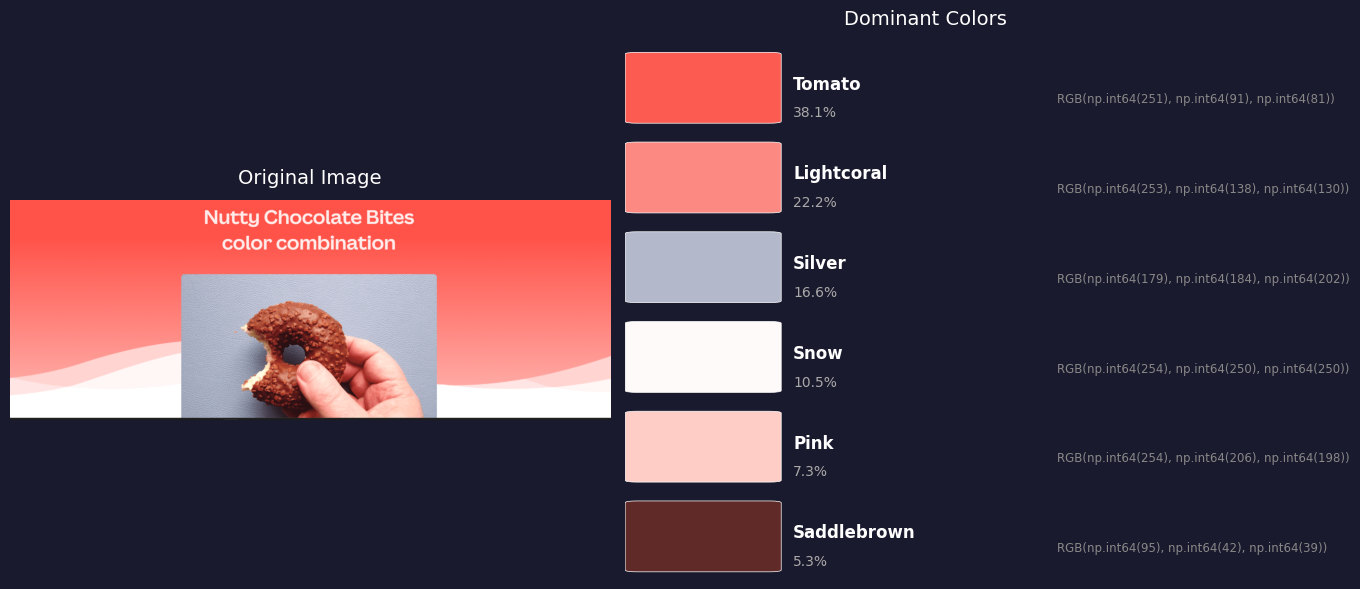


💾 Saved as color_palette.png


In [10]:
# ── Two-panel figure:
#    Left  → original image
#    Right → color swatches with name + % labels

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#1a1a2e')

# ── Panel 1: Original image ──────────────────────────────────────
axes[0].imshow(img)
axes[0].set_title('Original Image', color='white', fontsize=14, pad=12)
axes[0].axis('off')

# ── Panel 2: Color swatches ───────────────────────────────────────
axes[1].set_facecolor('#1a1a2e')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, K)
axes[1].axis('off')
axes[1].set_title('Dominant Colors', color='white', fontsize=14, pad=12)

for idx, r in enumerate(results):
    y        = K - idx - 1                     # draw top-to-bottom
    rgb_norm = tuple(v / 255 for v in r['rgb'])  # matplotlib needs 0-1

    # Color swatch rectangle
    rect = mpatches.FancyBboxPatch(
        (0.02, y + 0.1), 0.22, 0.75,
        boxstyle='round,pad=0.02',
        facecolor=rgb_norm, edgecolor='white', linewidth=0.5
    )
    axes[1].add_patch(rect)

    # Color name
    axes[1].text(0.28, y + 0.52, r['name'].title(),
                 color='white', fontsize=12, va='center', fontweight='bold')

    # Percentage
    axes[1].text(0.28, y + 0.2, f"{r['pct']:.1f}%",
                 color='#aaaaaa', fontsize=10, va='center')

    # RGB value
    axes[1].text(0.72, y + 0.35, f"RGB{r['rgb']}",
                 color='#888888', fontsize=8.5, va='center')

plt.tight_layout()
plt.savefig('color_palette.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('\n💾 Saved as color_palette.png')